In [1]:
import pandas as pd
df = pd.read_csv("ai_student_impact_dataset.csv")

## EDA

In [2]:
# EDA
print(f"baris dan kolom: \n{df.shape}\n")
print(f"Info: \n{df.info()}\n")
print(f"Melihat Tipe data: \n{df.dtypes}\n")

print(f'Cek Missing Values \n {df.isnull().sum()} \n')

baris dan kolom: 
(50000, 16)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  

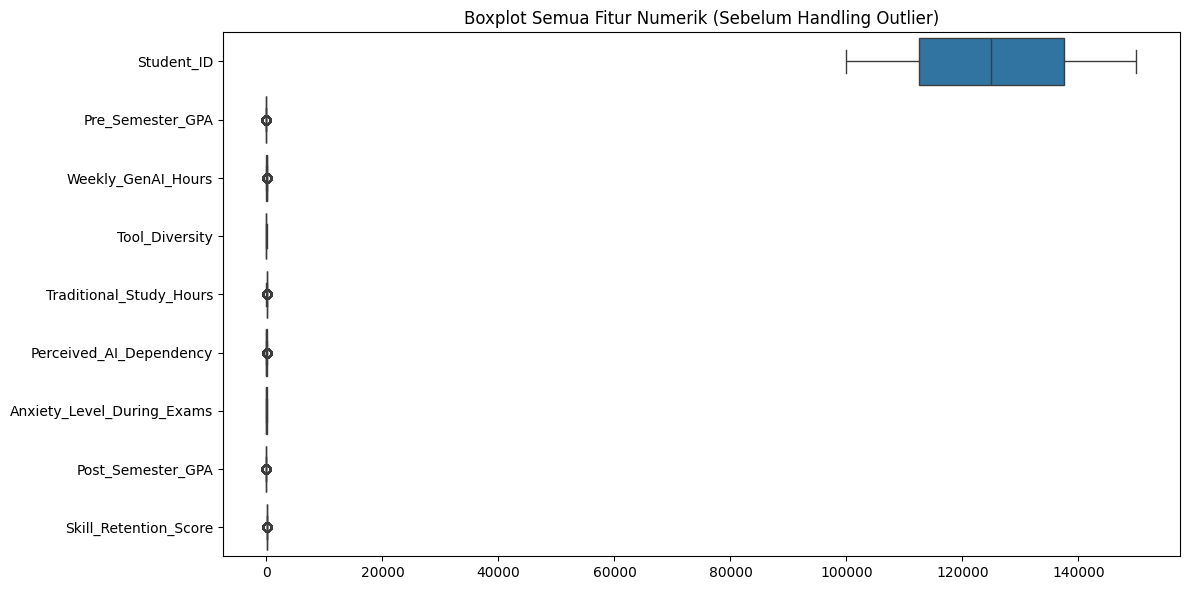

Jumlah outlier per kolom sebelum handling:
Student_ID: 0
Pre_Semester_GPA: 0
Weekly_GenAI_Hours: 869
Tool_Diversity: 0
Traditional_Study_Hours: 1
Perceived_AI_Dependency: 0
Anxiety_Level_During_Exams: 0
Post_Semester_GPA: 3
Skill_Retention_Score: 5


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# --- Pilih kolom numerik ---
num_cols = df.select_dtypes(include="number").columns

# 1️⃣ Visualisasi boxplot sebelum handling
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient='h')
plt.title("Boxplot Semua Fitur Numerik (Sebelum Handling Outlier)")
plt.tight_layout()
plt.show()

# 2️⃣ Hitung jumlah outlier per kolom pakai IQR
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 2.5 * IQR
    upper = Q3 + 2.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers

print("Jumlah outlier per kolom sebelum handling:")
for k, v in outlier_summary.items():
    print(f"{k}: {v}")



Jumlah outlier setelah handling:
Student_ID: 0
Pre_Semester_GPA: 0
Weekly_GenAI_Hours: 0
Tool_Diversity: 0
Traditional_Study_Hours: 0
Perceived_AI_Dependency: 0
Anxiety_Level_During_Exams: 0
Post_Semester_GPA: 0
Skill_Retention_Score: 0


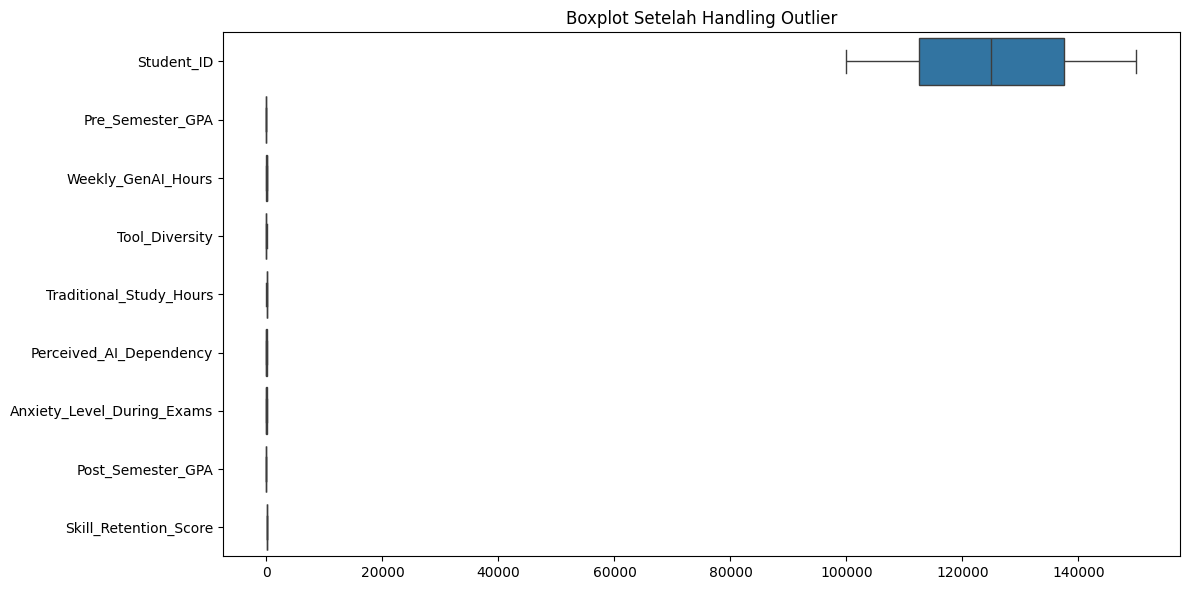

In [4]:
## handle Outlier
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

strategy = 'cap'  # pilihan: 'remove', 'cap', 'robust'

df_handled = df.copy()
if strategy == 'robust':
    # Robust scaling (tidak menghapus outlier, hanya menstabilkan distribusi)
    scaler = RobustScaler()
    df_handled[num_cols] = scaler.fit_transform(df_handled[num_cols])

else:
    if strategy == 'remove':
        # Buat mask global biar tidak kepotong berkali-kali
        mask = np.ones(len(df_handled), dtype=bool)

    for col in num_cols:
        Q1 = df_handled[col].quantile(0.25)
        Q3 = df_handled[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        if strategy == 'remove':
            mask &= (df_handled[col] >= lower) & (df_handled[col] <= upper)

        elif strategy == 'cap':
            df_handled[col] = df_handled[col].clip(lower, upper)

    if strategy == 'remove':
        df_handled = df_handled[mask]
        
outlier_summary_after = {}
for col in num_cols:
    Q1 = df_handled[col].quantile(0.25)
    Q3 = df_handled[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df_handled[col] < lower) | (df_handled[col] > upper)).sum()
    outlier_summary_after[col] = outliers

print("\nJumlah outlier setelah handling:")
for k, v in outlier_summary_after.items():
    print(f"{k}: {v}")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_handled[num_cols], orient='h')
plt.title("Boxplot Setelah Handling Outlier")
plt.tight_layout()
plt.show()

## OHE

In [5]:
df_handled.head()
df_handled.dtypes

Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency       float64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

from sklearn.model_selection import train_test_split

target = "Burnout_Risk_Level"

# 1. SPLIT FEATURE & TARGET
X = df.drop(columns=[target])
y = df[target]
X = X.drop(columns=["Student_ID"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 2. AUTO DETECT CATEGORICA
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# 3. FIT ENCODER HANYA DI TRAIN
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

# 4. BALIK KE DATAFRAME & GABUNG
train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)
test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)


X_train_final = pd.concat([X_train.drop(columns=categorical_cols), train_encoded_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols), test_encoded_df], axis=1)


In [12]:
# Scaler untuk Logisticregression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_final)
X_test_final = scaler.transform(X_test_final)

In [13]:
# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train)
 
# prediksi
y_pred = model.predict(X_test_final)

# Evaluasi
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion:
 [[1178  226 1132]
 [  78 1635 1556]
 [ 445 1170 2580]]

Classification Report:
               precision    recall  f1-score   support

        High       0.69      0.46      0.56      2536
         Low       0.54      0.50      0.52      3269
      Medium       0.49      0.62      0.55      4195

    accuracy                           0.54     10000
   macro avg       0.57      0.53      0.54     10000
weighted avg       0.56      0.54      0.54     10000



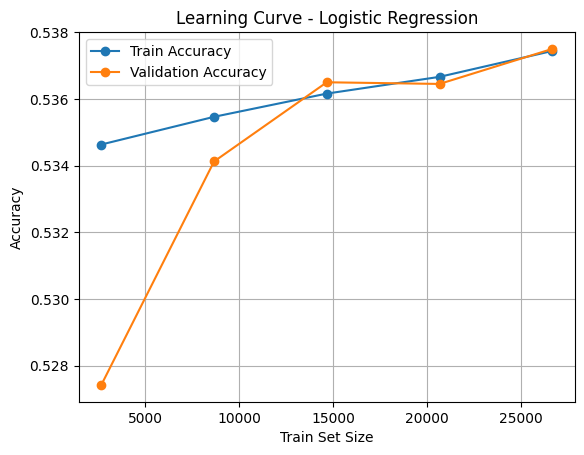

In [14]:
## learning curve
# learning curve
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
	
train_sizes, train_scores, val_scores = learning_curve(
	model, X_train_final, y_train, cv=3, scoring='accuracy'
)
	
# Rata-rata accuracy
train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)
	
plt.plot(train_sizes, train_scores_mean, 'o-', label="Train Accuracy")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation Accuracy")
plt.legend()
plt.xlabel("Train Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Logistic Regression")
plt.grid()
plt.show()

In [10]:
print(df["Burnout_Risk_Level"].value_counts())

Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


In [11]:
# HyperParameter Tunning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.stats import randint

# 1. Inisialisasi Model Dasar
rf = RandomForestClassifier(random_state=42)

# 2. Definisi Hyperparameter Distribution
# Pakai randint biar search space-nya lebih luas & dinamis
param_dist = {
    "n_estimators": randint(50, 500),
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None]
}

# 3. Setup Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,       # Coba 50 kombinasi random
    cv=3,            # 5-Fold Cross Validation
    n_jobs=-1,       # Pakai semua core CPU biar ngebut -> -1
    random_state=42,
    scoring="accuracy"
)

# 4. Training / Search
random_search.fit(X_train_final, y_train)

# 5. Output Best Parameters
print(f"Best Params: {random_search.best_params_}")
print(f"Best CV Score: {random_search.best_score_:.4f}")

# 6. Evaluasi Best Model pada Test Set
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_final)

print("     EVALUASI MODEL      ")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best Params: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 3, 'n_estimators': 393}
Best CV Score: 0.5330
     EVALUASI MODEL      
Test Accuracy: 0.5356

Classification Report:
              precision    recall  f1-score   support

        High       0.71      0.45      0.55      2536
         Low       0.55      0.43      0.48      3269
      Medium       0.48      0.67      0.56      4195

    accuracy                           0.54     10000
   macro avg       0.58      0.52      0.53     10000
weighted avg       0.56      0.54      0.53     10000


Confusion Matrix:
[[1146  179 1211]
 [  68 1399 1802]
 [ 411  973 2811]]
